# Tutorial Classification

> Tutorial Classification

In [ ]:
#| default_exp tutorial_1

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import download_medmnist

from monai.utils import set_determinism

set_determinism(0)

In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
image_path = '../_data/medmnist_data/'
info = download_medmnist('bloodmnist', image_path, download_only=True)
info

### Create Dataloader

In [ ]:
from fastai.vision.all import *

In [ ]:
bs, size = 6, 128

path = Path(image_path)
path_train = path/'train'
path_val = path/'val'

data_ops = {
    'blocks':       (BioImageBlock(cls=BioImageMulti), CategoryBlock()),
    'get_items':    get_image_files,
    'get_y':        parent_label,
    'splitter':     GrandparentSplitter(),
    'item_tfms':    [ScaleIntensity(min=0.0, max=1.0), RandCrop2D(size), RandRot90(prob=0.5), RandFlip(prob=0.75)],
    'bs': bs,
}

data = BioDataLoaders.from_source(
    path, 
    show_summary=False,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 13674 
validation images: 3418


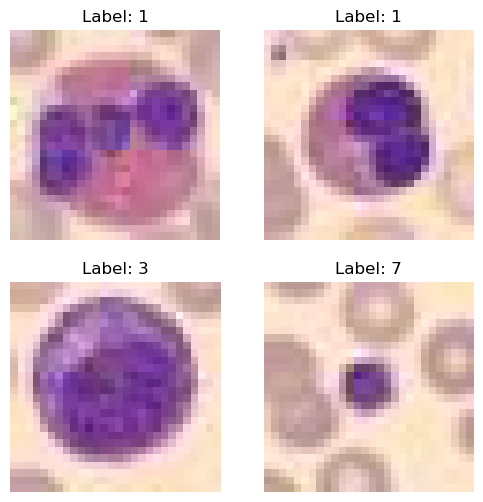

In [ ]:
data.show_batch(max_n=4)

### Load and train a 2D model

In [ ]:
# from monai.networks.nets import densenet121
#  model = densenet121(spatial_dims=2, in_channels=3, out_channels=8)

In [ ]:
model = resnet18

loss = CrossEntropyLossFlat()
metrics = accuracy

trainer = visionTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=True)

Sequential (Input shape: 6 x 3 x 28 x 28)
Layer (type)         Output Shape         Param #    Trainable 
                     6 x 64 x 14 x 14    
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     6 x 64 x 7 x 7      
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                         

epoch,train_loss,valid_loss,accuracy,time
0,1.110067,1.083420,0.630486,00:25


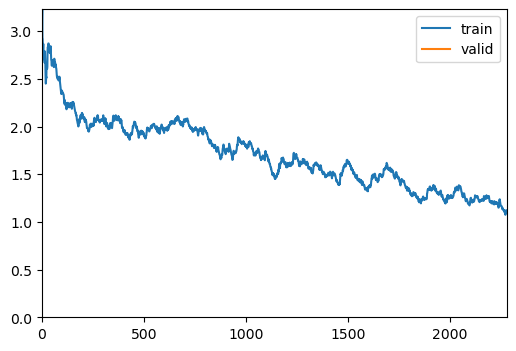

In [ ]:
trainer.fit(1)

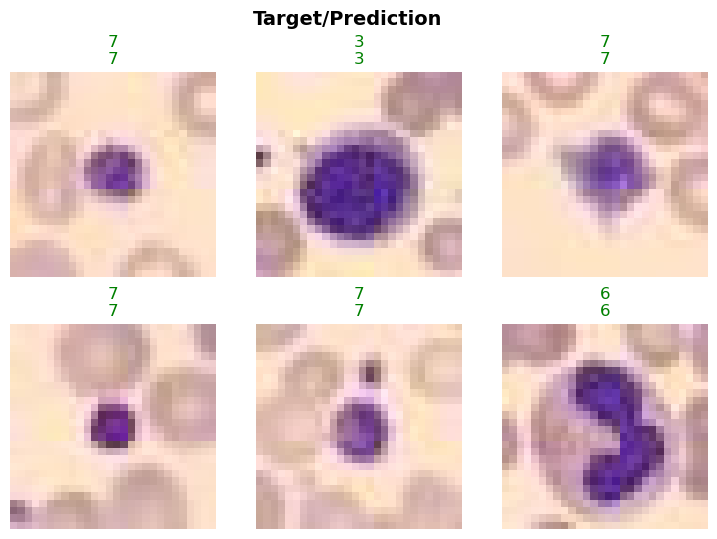

In [ ]:
trainer.show_results()

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!